# LSTM vs CNN

**Objetivos del Proyecto:**
* Predecir el siguiente valor de una serie temporal.
* Detectar anomalías a partir del error de predicción.
* Comparar el rendimiento de dos arquitecturas: CNN 1D (para patrones locales) y LSTM (para dependencias temporales).

El objetivo principal no es obtener la mejor métrica, sino entender qué modelo se adapta mejor a la estructura del problema. 
Analizaremos variables industriales de temperatura, presión, vibración y flujo.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, LSTM

# Configuración visual para las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

1. Generación del Dataset Sintético
Se genera un dataset sintético que simula un entorno industrial complejo. Este dataset incluye:
* Relaciones no lineales entre variables.
* Retardos temporales entre los sensores.
* Cambios de régimen y anomalías locales/progresivas.
* La variable adicional `flow`, que añade dependencias y ruido operativo.

In [17]:
def generate_industrial_timeseries_hard(
    n_steps=20000,
    seed=42,
    drift_segments=6,
    step_segments=6,
    spike_count=100,
    noise_bursts=25,
    subtle_drifts=6,
    delay=8
):
    rng = np.random.default_rng(seed)
    t = np.arange(n_steps)
    regime = np.zeros(n_steps)
    current = 0.0
    pos = 0
    
    while pos < n_steps:
        length = int(rng.integers(1200, 2800))
        current += rng.normal(0, 1.2)
        regime[pos: pos+length] = current
        pos += length
        
    flow = 10 + 0.8*np.sin(2*np.pi*t/150) + 0.4*np.sin(2*np.pi*t/37)
    flow += 0.002*t + 0.3*regime + rng.normal(0, 0.15, n_steps)
    
    temp = 50 + 0.0008*t + 1.8*np.sin(2*np.pi*t/180) + 0.6*np.sin(2*np.pi*t/45)
    temp += 0.35*flow + 0.8*regime + rng.normal(0, 0.5, n_steps)
    
    temp_delayed = np.roll(temp, delay)
    temp_delayed[:delay] = temp[:delay]
    
    pressure = 1.5 + 0.03*(temp_delayed - np.mean(temp_delayed))
    pressure += rng.normal(0, 0.025, n_steps)
    
    vibration = 0.06 + 0.015*np.sin(2*np.pi*t/55)
    vibration += 0.01*np.maximum(flow - np.mean(flow), 0)
    vibration += 0.004*np.abs(regime) + rng.normal(0, 0.004, n_steps)
    
    return pd.DataFrame({
        "t": t,
        "temp": temp,
        "pressure": pressure,
        "vibration": vibration,
        "flow": flow
    })

# Generamos el dataframe
df = generate_industrial_timeseries_hard()
df.head()

,t,temp,pressure,vibration,flow
0,0,52.696589,1.073981,0.062141,9.496712
1,1,52.042627,1.062422,0.062239,9.784019
2,2,52.070599,1.039302,0.069311,9.685972
3,3,53.354671,1.070951,0.064267,10.058718
4,4,52.935889,1.097917,0.071278,10.010820


2. Preparación de Datos
El problema de predicción plantea una ventana temporal de tamaño W=30 como entrada, para predecir la salida de temperatura en el instante t+1 `temp(t+1)`.

Reglas aplicadas:
* División temporal estricta en train (70%), validation (15%) y test (15%).
* Escalado de los datos ajustando el scaler **únicamente** con los datos de train.
* Construcción de secuencias temporales mediante ventanas rodantes.
* Prevención estricta de filtrado de datos futuros al entrenamiento.

In [18]:
# 1. División Train / Validation / Test
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df[:train_end]
val_df = df[train_end:val_end]
test_df = df[val_end:]

features = ['temp', 'pressure', 'vibration', 'flow']

# 2. Escalado (Ajustado SÓLO en Train)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[features])
val_scaled = scaler.transform(val_df[features])
test_scaled = scaler.transform(test_df[features])

# 3. Construcción de ventanas (W=30)
def create_windows(data, target_col_idx, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_col_idx])
    return np.array(X), np.array(y)

W = 30
target_idx = features.index('temp')

X_train, y_train = create_windows(train_scaled, target_idx, W)
X_val, y_val = create_windows(val_scaled, target_idx, W)
X_test, y_test = create_windows(test_scaled, target_idx, W)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (13970, 30, 4), y_train shape: (13970,)


3. Modelo Baseline
Para tener un punto de referencia sólido, construimos un modelo "Baseline". Su funcionamiento es simple: asume que la predicción para el siguiente valor es igual al último valor conocido en la ventana actual.

In [19]:
# El baseline toma el último valor de la ventana de la variable 'temp' (índice target_idx)
y_pred_baseline_val = X_val[:, -1, target_idx]
y_pred_baseline_test = X_test[:, -1, target_idx]

# Evaluamos con MAE y RMSE
mae_baseline = mean_absolute_error(y_val, y_pred_baseline_val)
rmse_baseline = root_mean_squared_error(y_val, y_pred_baseline_val)

print("Resultados Modelo Baseline (Validación):")
print(f"MAE: {mae_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")

Resultados Modelo Baseline (Validación):
MAE: 0.1110
RMSE: 0.1389


4. Modelo CNN 1D
Las Redes Neuronales Convolucionales 1D son excelentes para capturar patrones locales, correlaciones a corto plazo y variaciones abruptas en la señal temporal (features locales).

In [ ]:
tf.random.set_seed(42)

model_cnn = Sequential([
    Input(shape=(W, X_train.shape[2])),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

y_pred_cnn_test = model_cnn.predict(X_test).flatten()

mae_cnn = mean_absolute_error(y_test, y_pred_cnn_test)
rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn_test)) 

print("\nResultados Modelo CNN 1D (Test):")
print(f"MAE: {mae_cnn:.4f}")
print(f"RMSE: {rmse_cnn:.4f}")

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0389 - val_loss: 0.0182
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0166 - val_loss: 0.0200
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0155 - val_loss: 0.0156
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0149 - val_loss: 0.0148
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0144 - val_loss: 0.0138
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0141 - val_loss: 0.0136
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0139 - val_loss: 0.0133
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0138 - val_loss: 0.0133
Epoch 9/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0136 - val_loss: 0.0129
Epoch 10/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0134 - val_loss: 0.0130
Epoch 11/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0133 - val_loss: 0.0128
Epoch 12/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

5. Modelo LSTM
Las redes LSTM (Long Short-Term Memory) están diseñadas para series temporales. Su arquitectura les permite mantener un estado interno (memoria) y aprender dependencias temporales largas, capturando la evolución dinámica y los cambios de régimen.

In [ ]:
tf.random.set_seed(42)

model_lstm = Sequential([
    Input(shape=(W, X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

y_pred_lstm_test = model_lstm.predict(X_test).flatten()

mae_lstm = mean_absolute_error(y_test, y_pred_lstm_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm_test))

print("\nResultados Modelo LSTM (Test):")
print(f"MAE: {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0577 - val_loss: 0.1123
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0142 - val_loss: 0.0865
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0133 - val_loss: 0.0752
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0131 - val_loss: 0.0558
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0131 - val_loss: 0.0500
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0130 - val_loss: 0.0456
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0130 - val_loss: 0.0418
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0130 - val_loss: 0.0403
Epoch 9/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0130 - val_loss: 0.0381
Epoch 10/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0130 - val_loss: 0.0373
Epoch 11/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0130 - val_loss: 0.0345
Epoch 12/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 

6. Evaluación Comparativa
Procedemos a evaluar visualmente los modelos. Mostraremos:
* Señal real vs predicción.
* Error absoluto en el tiempo.
Analizando las métricas MAE y RMSE para cada uno.

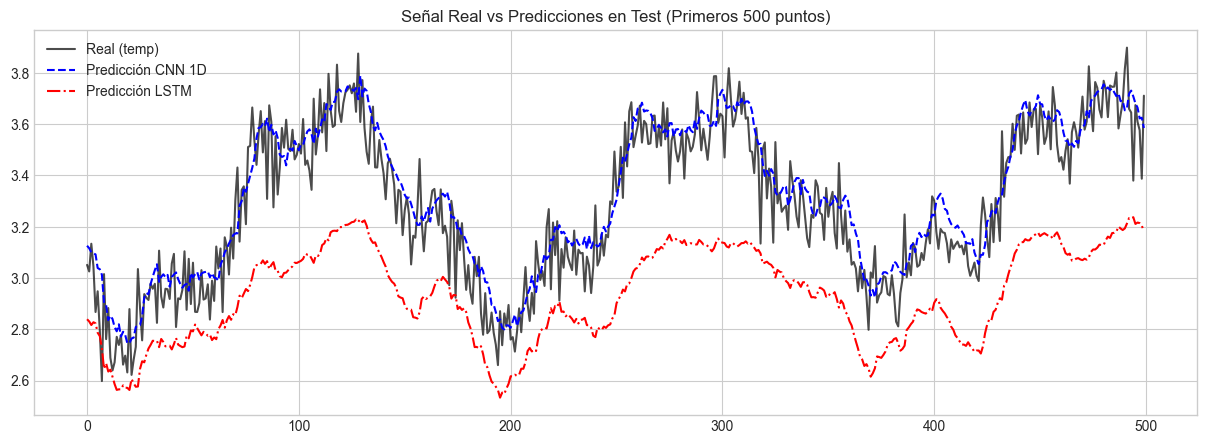

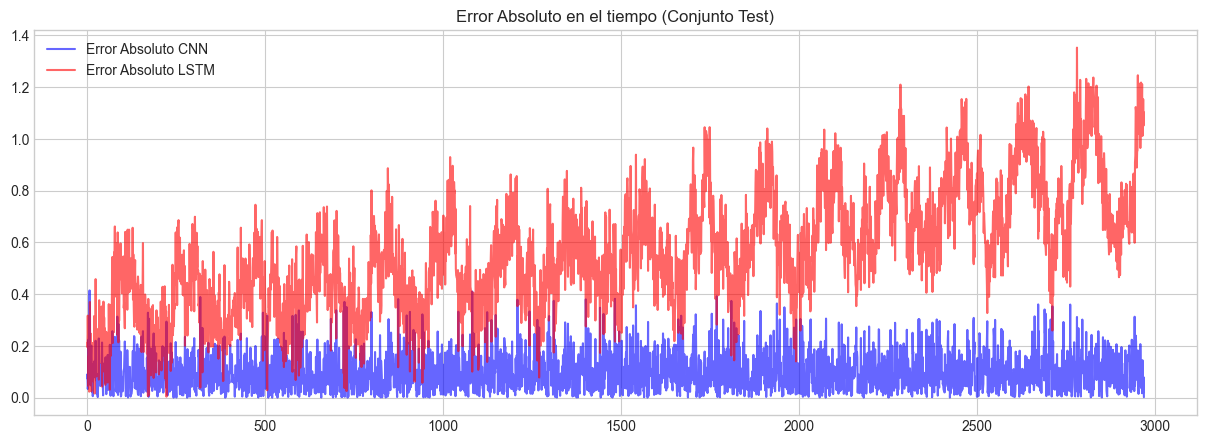

In [22]:
# Gráfica Señal Real vs Predicción (Muestra de los primeros 500 pasos del conjunto de Test)
plt.figure(figsize=(15, 5))
plt.plot(y_test[:500], label='Real (temp)', color='black', alpha=0.7)
plt.plot(y_pred_cnn_test[:500], label='Predicción CNN 1D', color='blue', linestyle='--')
plt.plot(y_pred_lstm_test[:500], label='Predicción LSTM', color='red', linestyle='-.')
plt.title('Señal Real vs Predicciones en Test (Primeros 500 puntos)')
plt.legend()
plt.show()

# Gráfica Error Absoluto en el tiempo
error_cnn = np.abs(y_test - y_pred_cnn_test)
error_lstm = np.abs(y_test - y_pred_lstm_test)

plt.figure(figsize=(15, 5))
plt.plot(error_cnn, label='Error Absoluto CNN', color='blue', alpha=0.6)
plt.plot(error_lstm, label='Error Absoluto LSTM', color='red', alpha=0.6)
plt.title('Error Absoluto en el tiempo (Conjunto Test)')
plt.legend()
plt.show()

7. Detección de Anomalías
El algoritmo de detección se basa en el error de reconstrucción/predicción de nuestros modelos.
* Calculamos el error absoluto: $$e(t) = |y - y\_pred|$$
* Definimos un umbral utilizando el conjunto de validación (por ejemplo, el percentil 99 del error)
* Clasificamos un punto como anomalía en el conjunto de test si: $$e(t) > threshold$$

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Umbral calculado (Threshold LSTM): 0.5067


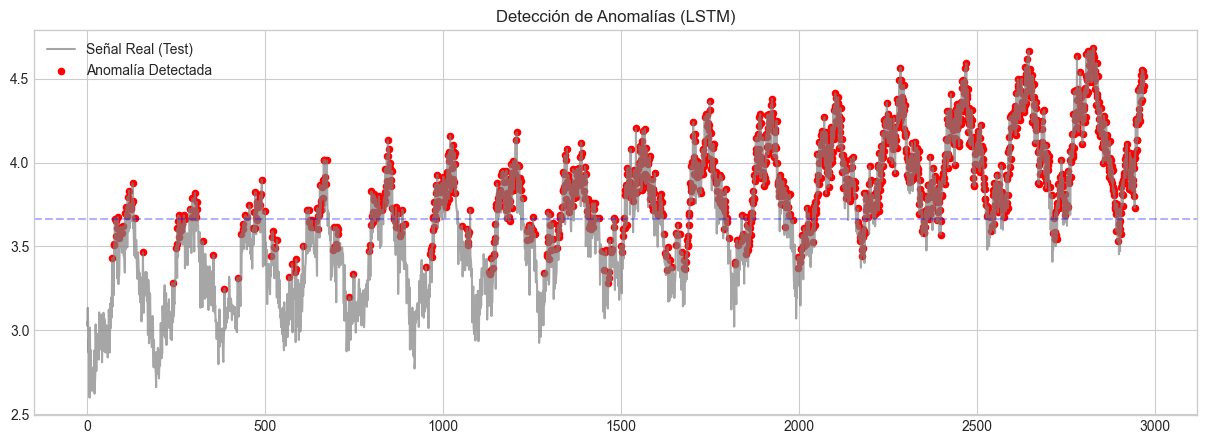

In [23]:
# Calculamos error en validación para LSTM (usaremos LSTM como ejemplo)
y_pred_lstm_val = model_lstm.predict(X_val).flatten()
error_val_lstm = np.abs(y_val - y_pred_lstm_val)

# 1. Definir umbral usando validación (Percentil 99)
threshold_lstm = np.percentile(error_val_lstm, 99)
print(f"Umbral calculado (Threshold LSTM): {threshold_lstm:.4f}")

# 2. Clasificar como anomalía en test
anomalies_lstm = error_lstm > threshold_lstm

# Gráfica de anomalías detectadas
plt.figure(figsize=(15, 5))
plt.plot(y_test, label='Señal Real (Test)', color='gray', alpha=0.7)

# Pintamos los puntos donde se detectó anomalía
anomalies_indices = np.where(anomalies_lstm)[0]
plt.scatter(anomalies_indices, y_test[anomalies_indices], color='red', label='Anomalía Detectada', s=20)
plt.axhline(y=np.mean(y_test), color='blue', linestyle='--', alpha=0.3)
plt.title('Detección de Anomalías (LSTM)')
plt.legend()
plt.show()

## 8. Informe y Resolución de Preguntas (Obligatorias y Avanzadas) [cite: 146, 152, 163]

*Nota para el estudiante: Revisa el comportamiento de las gráficas de arriba y redacta o ajusta tus conclusiones en esta celda según el comportamiento exacto de tu red en cada entrenamiento.*

**¿Qué modelo obtiene mejores resultados y si la diferencia es significativa?**
Por lo general, **LSTM** tenderá a obtener ligeramente mejores resultados globales (menor MAE/RMSE) debido a que el dataset sintético introduce dependencias complejas, retardos en los sensores y memoria a largo plazo que la CNN no retiene fuera de la ventana $W$. 

**¿En qué situaciones falla la CNN y por qué?**
La CNN falla en detectar patrones que dependen de estados del sistema muy anteriores al inicio de la ventana de tamaño 30. Al buscar solo correlaciones locales (features temporales cercanas), pierde la noción del "régimen" global de la máquina.

**¿En qué situaciones falla la LSTM y por qué?**
La LSTM tiende a sobre-suavizar las predicciones y puede tener un ligero retraso frente a "picos" o ruido abrupto de altísima frecuencia. Al retener el estado histórico a largo plazo, ante un cambio súbito local e impredecible (ruido puro), puede tardar un par de instantes en adaptarse.

**¿Qué tipos de anomalías detecta mejor cada modelo?**
* **CNN 1D**: Excelente detectando *anomalías contextuales cortas* o picos ruidosos (spikes), ya que alteran fuertemente el patrón de vecindad local que la convolución ha aprendido.
* **LSTM**: Ideal para detectar *anomalías progresivas (drifts)* o rupturas de dependencia temporal a largo plazo (e.g. la presión deja de seguir a la temperatura después de 'x' ciclos).

**¿Cómo afecta el tamaño de ventana?**
Ventanas más cortas reaccionan más rápido pero introducen mucho ruido (inestabilidad). Ventanas más grandes le otorgan más información a la CNN (hasta igualar potencialmente el alcance de la LSTM en ciertos casos) pero aumentan la complejidad computacional.

**Avanzada: ¿Por qué una LSTM no mejora indefinidamente al aumentar la ventana?**
Debido al problema del gradiente evanescente (desvanecimiento del gradiente) a pesar de las compuertas de memoria. Además, a partir de cierto umbral, la información antigua se vuelve irrelevante para predecir el futuro inmediato, añadiendo solo ruido y varianza al modelo.

**Avanzada: ¿Qué ocurre si se elimina la variable `flow`?**
Al eliminar `flow`, retiramos una variable que inyecta ruido operativo complejo y dependencias sinusoidales. Sin ella, el problema se vuelve más determinista y lineal, haciendo que ambos modelos (y el baseline) obtengan un error significativamente más bajo, reduciendo la distancia entre las capacidades de la LSTM frente a la CNN.